# Графики результатов бенчмарка

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
with open('benchmark_results.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

## Извлекаем метрики

In [ ]:
from pathlib import Path

RESULTS_PATH = Path("benchmark_results.json")
BENCHMARKS_PATH = Path("benchmarks.json")

with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    runs = json.load(f)
if isinstance(runs, dict):
    runs = [runs]

try:
    with open(BENCHMARKS_PATH, "r", encoding="utf-8") as f:
        scenarios = json.load(f)
    difficulty_map = {s["id"]: s.get("difficulty", "unknown") for s in scenarios}
except FileNotFoundError:
    difficulty_map = {}

def site_of(sid: str) -> str:
    return sid.split("_", 1)[0] if sid else "unknown"

def scenario_row(r: dict) -> dict:
    sid = r.get("scenario_id", "")
    traj = r.get("trajectory", []) or []
    usage = r.get("usage") or {}
    timing = r.get("timing") or {}
    error_steps = sum(1 for s in traj if s.get("error"))
    useless_steps = sum(1 for s in traj if not s.get("changed_state"))
    cp_total = r.get("checkpoints_total") or 0
    cp_reached = r.get("checkpoints_reached") or 0
    return {
        "scenario_id": sid,
        "site": site_of(sid),
        "difficulty": difficulty_map.get(sid, "unknown"),
        "success": bool(r.get("success")),
        "visited_eval_url": bool(r.get("visited_eval_url")),
        "stopped_correctly": bool(r.get("stopped_correctly")),
        "steps_taken": r.get("steps_taken") or 0,
        "duration_sec": timing.get("duration_sec") or 0.0,
        "total_tokens": usage.get("total_tokens") or 0,
        "actions": len(traj),
        "error_steps": error_steps,
        "useless_steps": useless_steps,
        "cp_progress": (cp_reached / cp_total) if cp_total else None,
    }

def aggregate(df: pd.DataFrame) -> dict:
    n = len(df)
    if n == 0:
        return {}
    actions = df["actions"].sum()
    return {
        "N": n,
        "SuccessRate,%": round(df["success"].mean() * 100, 1),
        "VisitedRate,%": round(df["visited_eval_url"].mean() * 100, 1),
        "StoppedCorrectly,%": round(df["stopped_correctly"].mean() * 100, 1),
        "AvgCheckpointProgress": round(df["cp_progress"].dropna().mean() or 0, 3),
        "AvgSteps": round(df["steps_taken"].mean(), 2),
        "AvgSteps(success)": round(df.loc[df["success"], "steps_taken"].mean(), 2)
                              if df["success"].any() else None,
        "AvgDur,s": round(df["duration_sec"].mean(), 2),
        "AvgTokens": int(df["total_tokens"].mean()) if df["total_tokens"].any() else 0,
        "ErrRatio": round(df["error_steps"].sum() / actions, 3) if actions else 0.0,
        "UselessRatio": round(df["useless_steps"].sum() / actions, 3) if actions else 0.0,
    }

def group_table(df: pd.DataFrame, by: str) -> pd.DataFrame:
    rows = []
    for key, sub in df.groupby(by, dropna=False):
        row = {by: key, **aggregate(sub)}
        rows.append(row)
    tbl = pd.DataFrame(rows).sort_values(by).reset_index(drop=True)
    return tbl

# вывод по каждому прогону
for i, run in enumerate(runs, start=1):
    agent = run.get("agent_name", "unknown")
    model = run.get("model") or (run["results"][0].get("extra", {}) or {}).get("model", "")
    ts = run.get("timestamp", "")
    print("=" * 80)
    print(f"RUN {i}/{len(runs)} | agent={agent} | model={model} | ts={ts}")
    print("=" * 80)

    df = pd.DataFrame([scenario_row(r) for r in run.get("results", [])])
    if df.empty:
        print("No results in this run.")
        continue

    overall = pd.DataFrame([{"scope": "ALL", **aggregate(df)}])
    print("\n— Итог по прогону —")
    display(overall)

    print("\n— По уровням сложности —")
    diff_order = ["easy", "medium", "hard", "unknown"]
    diff_tbl = group_table(df, "difficulty")
    diff_tbl["difficulty"] = pd.Categorical(diff_tbl["difficulty"], diff_order, ordered=True)
    diff_tbl = diff_tbl.sort_values("difficulty").reset_index(drop=True)
    display(diff_tbl)

    print("\n— По сайтам —")
    display(group_table(df, "site"))

RUN 1/3 | agent=deepseek/deepseek-chat-v3.1 | model=deepseek/deepseek-chat-v3.1 | ts=2026-05-06T03:13:06.255179

— Итог по прогону —


,scope,N,"SuccessRate,%","VisitedRate,%","StoppedCorrectly,%",AvgCheckpointProgress,AvgSteps,AvgSteps(success),"AvgDur,s",AvgTokens,ErrRatio,UselessRatio
0,ALL,60,25.0,20.0,8.3,0.528,7.42,8.4,132.49,37727,0.176,0.686



— По уровням сложности —


,difficulty,N,"SuccessRate,%","VisitedRate,%","StoppedCorrectly,%",AvgCheckpointProgress,AvgSteps,AvgSteps(success),"AvgDur,s",AvgTokens,ErrRatio,UselessRatio
0,unknown,60,25.0,20.0,8.3,0.528,7.42,8.4,132.49,37727,0.176,0.686



— По сайтам —


...

,scope,N,"SuccessRate,%","VisitedRate,%","StoppedCorrectly,%",AvgCheckpointProgress,AvgSteps,AvgSteps(success),"AvgDur,s",AvgTokens,ErrRatio,UselessRatio
0,ALL,60,65.0,60.0,60.0,0.653,11.63,9.79,98.78,0,0.074,0.765



— По уровням сложности —


,difficulty,N,"SuccessRate,%","VisitedRate,%","StoppedCorrectly,%",AvgCheckpointProgress,AvgSteps,AvgSteps(success),"AvgDur,s",AvgTokens,ErrRatio,UselessRatio
0,unknown,60,65.0,60.0,60.0,0.653,11.63,9.79,98.78,0,0.074,0.765



— По сайтам —


,site,N,"SuccessRate,%","VisitedRate,%","StoppedCorrectly,%",AvgCheckpointProgress,AvgSteps,AvgSteps(success),"AvgDur,s",AvgTokens,ErrRatio,UselessRatio
0,citilink,4,25.0,25.0,25.0,0.625,10.75,3.00,79.97,0,0.048,0.714
1,consultant,4,100.0,100.0,100.0,0.900,10.75,10.75,74.39,0,0.015,0.773
2,consultantnews,4,75.0,75.0,75.0,0.875,4.75,4.33,37.39,0,0.273,0.636
3,hermitage,11,63.6,45.5,45.5,0.680,9.27,5.43,57.62,0,0.120,0.720
4,lamoda,4,25.0,25.0,25.0,0.583,18.25,16.00,313.94,0,0.080,0.735
5,otello,4,75.0,75.0,75.0,0.217,14.00,12.33,104.04,0,0.000,0.870
6,rzd,11,81.8,72.7,72.7,0.674,12.64,13.11,104.82,0,0.121,0.766
7,sunlight,4,75.0,75.0,75.0,0.812,9.75,7.33,78.97,0,0.062,0.578
8,sutochno,10,70.0,70.0,70.0,0.625,13.20,10.43,102.00,0,0.021,0.867
9,yafisha,4,25.0,25.0,25.0,0.500,13.00,19.00,91.24,0,0.133,0.667


## Success Rate

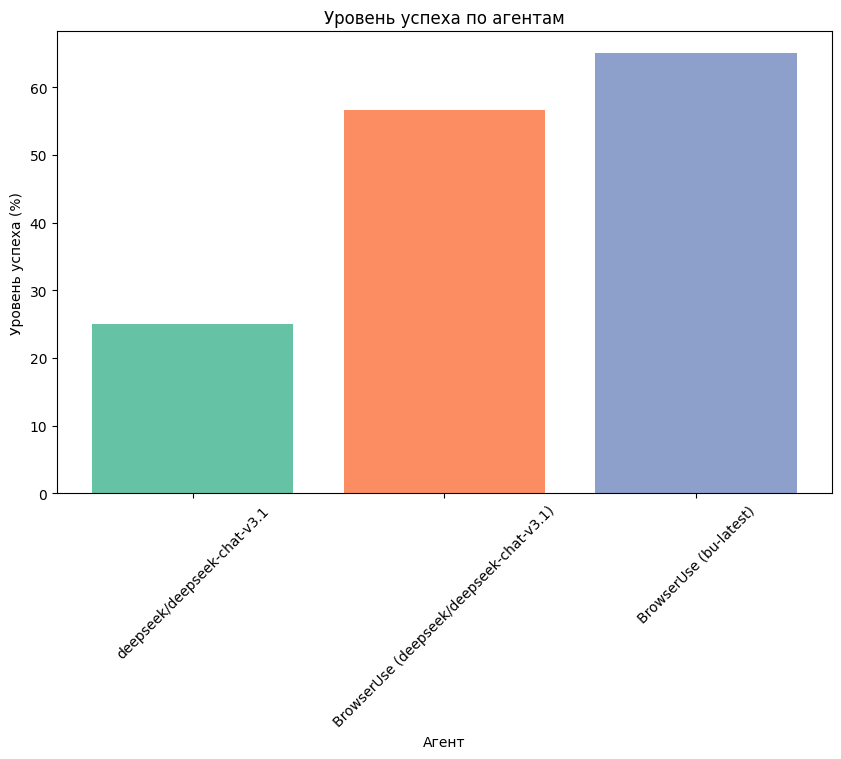

In [ ]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Set2(range(len(agents)))
plt.bar(agents, success_rates, color=colors)
plt.xlabel('Агент')
plt.ylabel('Уровень успеха (%)')
plt.title('Уровень успеха по агентам')
plt.xticks(rotation=45)
plt.show()

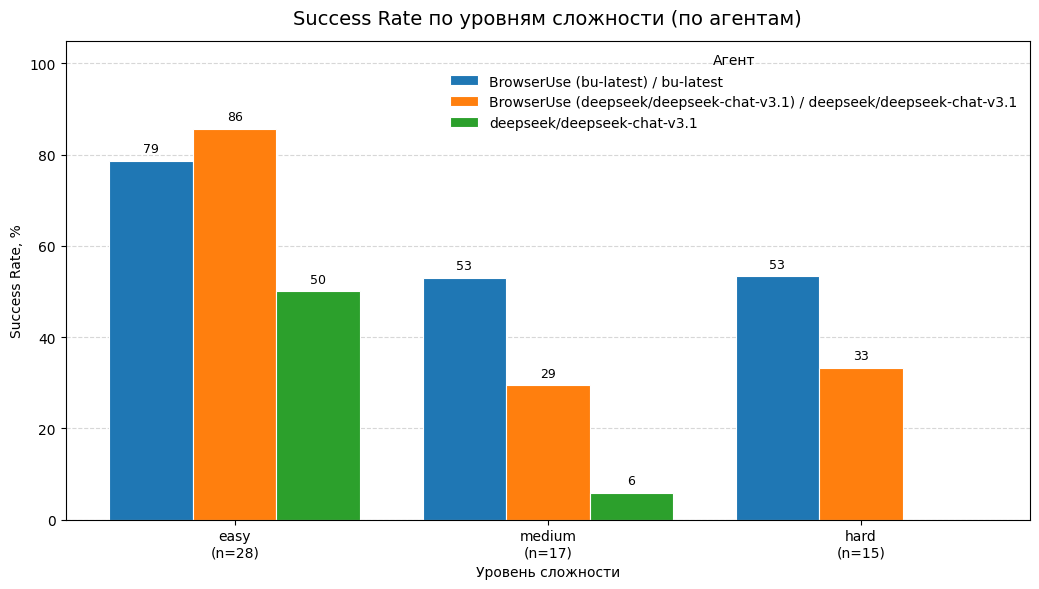

Сохранено: output/success_rate_by_difficulty.png  и  output/success_rate_by_difficulty.csv


In [ ]:

with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    runs = json.load(f)
if isinstance(runs, dict):
    runs = [runs]

with open(BENCHMARKS_PATH, "r", encoding="utf-8") as f:
    scenarios = json.load(f)

difficulty_map = {s["id"]: s.get("difficulty", "unknown") for s in scenarios}

# сбор длинной таблицы
rows = []
for run in runs:
    agent = run.get("agent_name", "unknown")
    model = run.get("model") or ((run.get("results") or [{}])[0].get("extra", {}) or {}).get("model", "")
    label = f"{agent} / {model}" if model and model != agent else str(agent)
    for r in run.get("results", []):
        sid = r.get("scenario_id", "")
        rows.append({
            "agent": label,
            "scenario_id": sid,
            "difficulty": difficulty_map.get(sid, "unknown"),
            "success": bool(r.get("success")),
        })

df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError("В файле нет результатов для построения графика.")

missing = df[df["difficulty"] == "unknown"]["scenario_id"].unique().tolist()
if missing:
    print(f"⚠ Для {len(missing)} сценариев не найден уровень сложности в benchmarks.json, "
          f"они попадут в группу 'unknown'. Примеры: {missing[:5]}")

# агрегирование: success rate, %
pivot = (
    df.groupby(["difficulty", "agent"])["success"]
      .mean().mul(100).round(1)
      .unstack("agent").fillna(0)
)

# упорядочим сложности
order = [d for d in ["easy", "medium", "hard", "unknown"] if d in pivot.index]
pivot = pivot.loc[order]

# количество сценариев в каждой группе - для подписей под осью X
counts_per_difficulty = df.drop_duplicates("scenario_id") \
                          .groupby("difficulty")["scenario_id"].count()

# график
agents = list(pivot.columns)
levels = list(pivot.index)
x = np.arange(len(levels))
bar_w = 0.8 / max(len(agents), 1)

fig, ax = plt.subplots(figsize=(max(8, 2.2 * len(levels) + 1.3 * len(agents)), 6))
colors = plt.cm.tab10.colors

for i, agent in enumerate(agents):
    offsets = x - 0.4 + bar_w * (i + 0.5)
    values = pivot[agent].values
    bars = ax.bar(offsets, values, width=bar_w,
                  label=agent, color=colors[i % len(colors)],
                  edgecolor="white", linewidth=0.8)
    for rect, v in zip(bars, values):
        if v > 0:
            ax.text(rect.get_x() + rect.get_width() / 2, v + 1.3,
                    f"{v:.0f}", ha="center", va="bottom", fontsize=9)

xtick_labels = [f"{lvl}\n(n={counts_per_difficulty.get(lvl, 0)})" for lvl in levels]
ax.set_title("Success Rate по уровням сложности (по агентам)", fontsize=14, pad=12)
ax.set_xlabel("Уровень сложности")
ax.set_ylabel("Success Rate, %")
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels)
ax.set_ylim(0, 105)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend(title="Агент", loc="upper right", frameon=False)

plt.tight_layout()


plt.show()

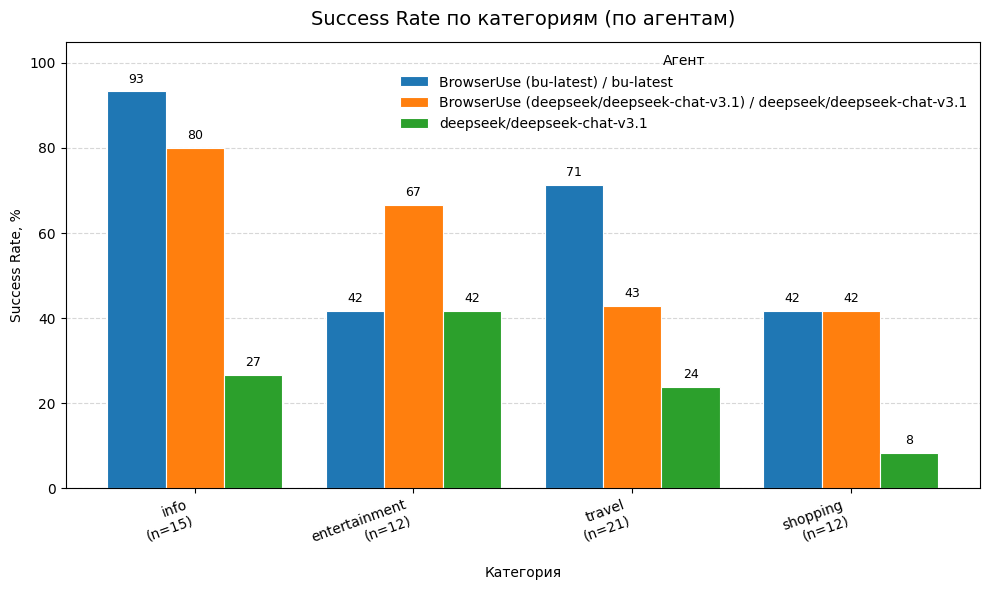

Сохранено: output/success_rate_by_category.png  и  output/success_rate_by_category.csv


In [ ]:
with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    runs = json.load(f)
if isinstance(runs, dict):
    runs = [runs]

with open(BENCHMARKS_PATH, "r", encoding="utf-8") as f:
    scenarios = json.load(f)

category_map = {s["id"]: s.get("type", "unknown") for s in scenarios}

# сбор длинной таблицы
rows = []
for run in runs:
    agent = run.get("agent_name", "unknown")
    model = run.get("model") or ((run.get("results") or [{}])[0].get("extra", {}) or {}).get("model", "")
    label = f"{agent} / {model}" if model and model != agent else str(agent)
    for r in run.get("results", []):
        sid = r.get("scenario_id", "")
        rows.append({
            "agent": label,
            "scenario_id": sid,
            "category": category_map.get(sid, "unknown"),
            "success": bool(r.get("success")),
        })

df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError("В файле нет результатов для построения графика.")

missing = df[df["category"] == "unknown"]["scenario_id"].unique().tolist()
if missing:
    print(f"⚠ Для {len(missing)} сценариев не найдена категория в benchmarks.json, "
          f"они попадут в группу 'unknown'. Примеры: {missing[:5]}")

# агрегирование: success rate, %
pivot = (
    df.groupby(["category", "agent"])["success"]
      .mean().mul(100).round(1)
      .unstack("agent").fillna(0)
)

# упорядочим категории по средней успешности (лучшие слева)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

counts_per_category = df.drop_duplicates("scenario_id") \
                        .groupby("category")["scenario_id"].count()

# график
agents = list(pivot.columns)
cats = list(pivot.index)
x = np.arange(len(cats))
bar_w = 0.8 / max(len(agents), 1)

fig, ax = plt.subplots(figsize=(max(10, 1.3 * len(cats) + 1.3 * len(agents)), 6))
colors = plt.cm.tab10.colors

for i, agent in enumerate(agents):
    offsets = x - 0.4 + bar_w * (i + 0.5)
    values = pivot[agent].values
    bars = ax.bar(offsets, values, width=bar_w,
                  label=agent, color=colors[i % len(colors)],
                  edgecolor="white", linewidth=0.8)
    for rect, v in zip(bars, values):
        if v > 0:
            ax.text(rect.get_x() + rect.get_width() / 2, v + 1.3,
                    f"{v:.0f}", ha="center", va="bottom", fontsize=9)

xtick_labels = [f"{c}\n(n={counts_per_category.get(c, 0)})" for c in cats]
ax.set_title("Success Rate по категориям (по агентам)", fontsize=14, pad=12)
ax.set_xlabel("Категория")
ax.set_ylabel("Success Rate, %")
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=20, ha="right")
ax.set_ylim(0, 105)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend(title="Агент", loc="upper right", frameon=False)

plt.tight_layout()


plt.show()

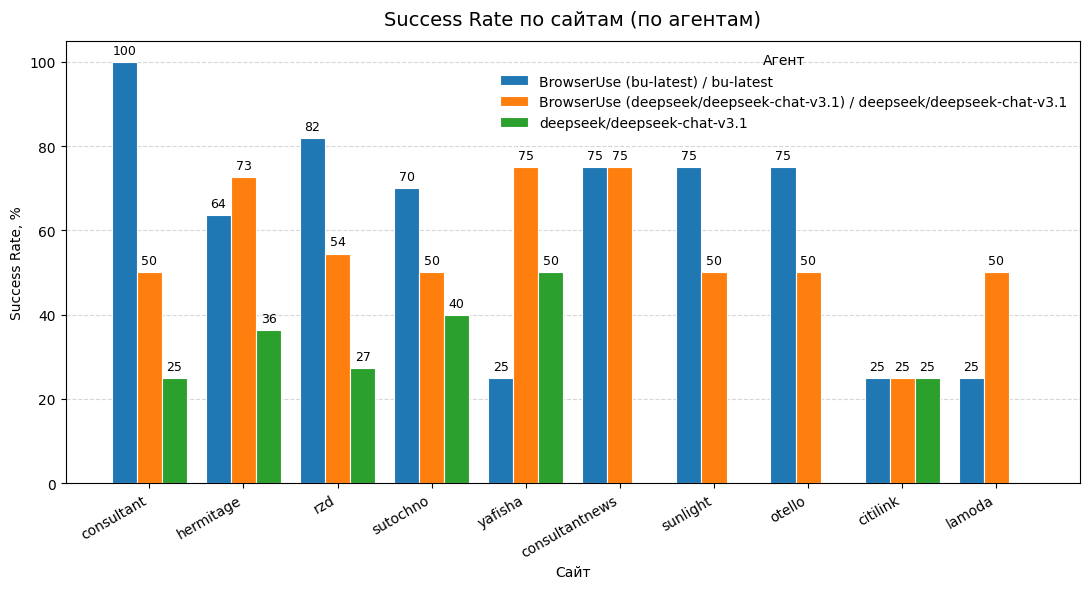

Сохранено: output/success_rate_by_site.png  и  output/success_rate_by_site.csv


In [ ]:
with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    runs = json.load(f)
if isinstance(runs, dict):
    runs = [runs]

def site_of(sid: str) -> str:
    return sid.split("_", 1)[0] if sid else "unknown"

# сбор длинной таблицы
rows = []
for run in runs:
    agent = run.get("agent_name", "unknown")
    model = run.get("model") or ((run.get("results") or [{}])[0].get("extra", {}) or {}).get("model", "")
    label = f"{agent} / {model}" if model and model != agent else str(agent)
    for r in run.get("results", []):
        rows.append({
            "agent": label,
            "site": site_of(r.get("scenario_id", "")),
            "success": bool(r.get("success")),
        })

df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError("В файле нет результатов для построения графика.")

# success rate по (agent, site), %
pivot = (
    df.groupby(["site", "agent"])["success"]
      .mean()
      .mul(100)
      .round(1)
      .unstack("agent")
      .fillna(0)
)

# отсортируем сайты по средней успешности, лучшие слева
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

# график
agents = list(pivot.columns)
sites = list(pivot.index)
n_agents = len(agents)
x = np.arange(len(sites))
bar_w = 0.8 / max(n_agents, 1)

fig, ax = plt.subplots(figsize=(max(10, 1.1 * len(sites)), 6))
colors = plt.cm.tab10.colors

for i, agent in enumerate(agents):
    offsets = x - 0.4 + bar_w * (i + 0.5)
    values = pivot[agent].values
    bars = ax.bar(offsets, values, width=bar_w,
                  label=agent, color=colors[i % len(colors)],
                  edgecolor="white", linewidth=0.8)
    for rect, v in zip(bars, values):
        if v > 0:
            ax.text(rect.get_x() + rect.get_width() / 2, v + 1.2,
                    f"{v:.0f}", ha="center", va="bottom", fontsize=9)

ax.set_title("Success Rate по сайтам (по агентам)", fontsize=14, pad=12)
ax.set_xlabel("Сайт")
ax.set_ylabel("Success Rate, %")
ax.set_xticks(x)
ax.set_xticklabels(sites, rotation=30, ha="right")
ax.set_ylim(0, 105)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend(title="Агент", loc="upper right", frameon=False)

plt.tight_layout()

plt.show()

## Среднее время выполнения

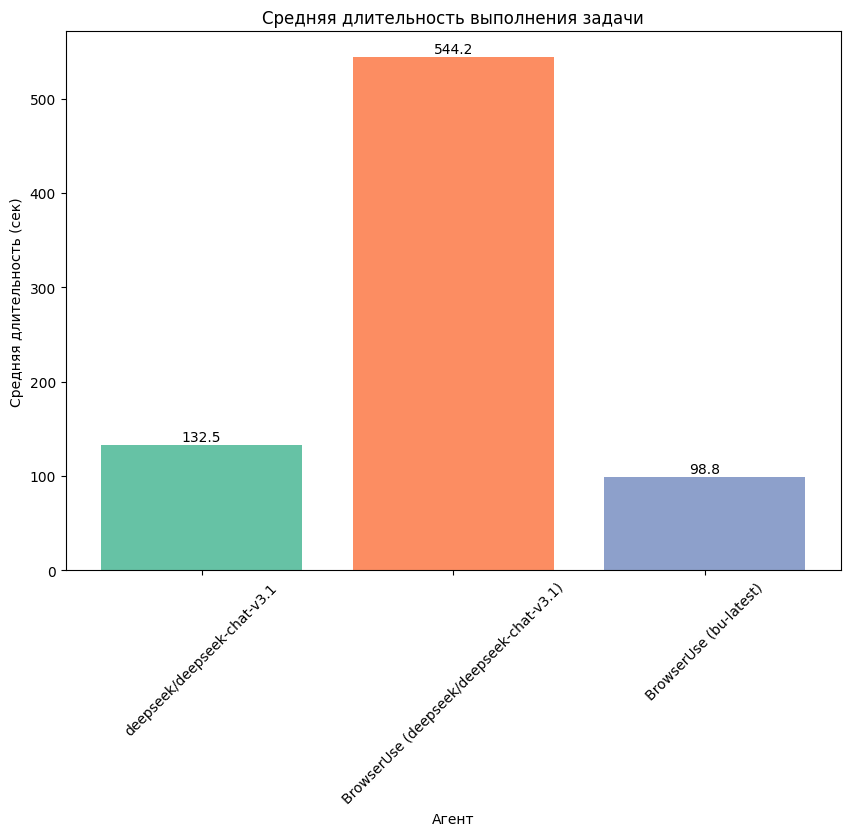

In [ ]:
plt.figure(figsize=(10, 7))
colors = plt.cm.Set2(range(len(agents)))
bars = plt.bar(agents, avg_durations, color=colors)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{height:.1f}', ha='center', va='bottom', fontsize=10)
plt.xlabel('Агент')
plt.ylabel('Средняя длительность (сек)')
plt.title('Средняя длительность выполнения задачи')
plt.xticks(rotation=45)
plt.show()

## Среднее число шагов

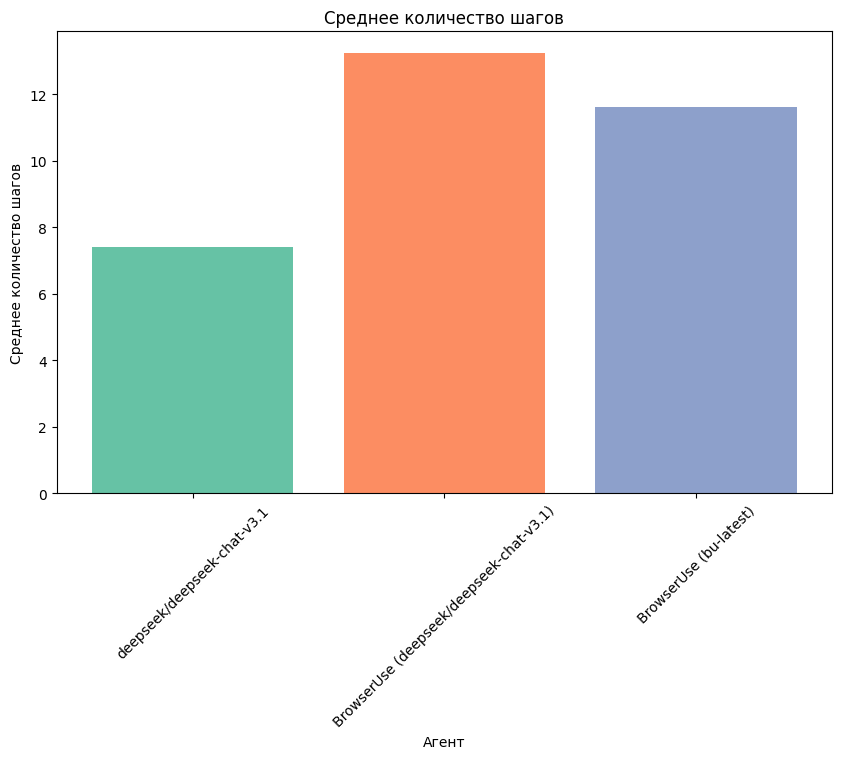

In [ ]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Set2(range(len(agents)))
plt.bar(agents, avg_steps, color=colors)
plt.xlabel('Агент')
plt.ylabel('Среднее количество шагов')
plt.title('Среднее количество шагов')
plt.xticks(rotation=45)
plt.show()

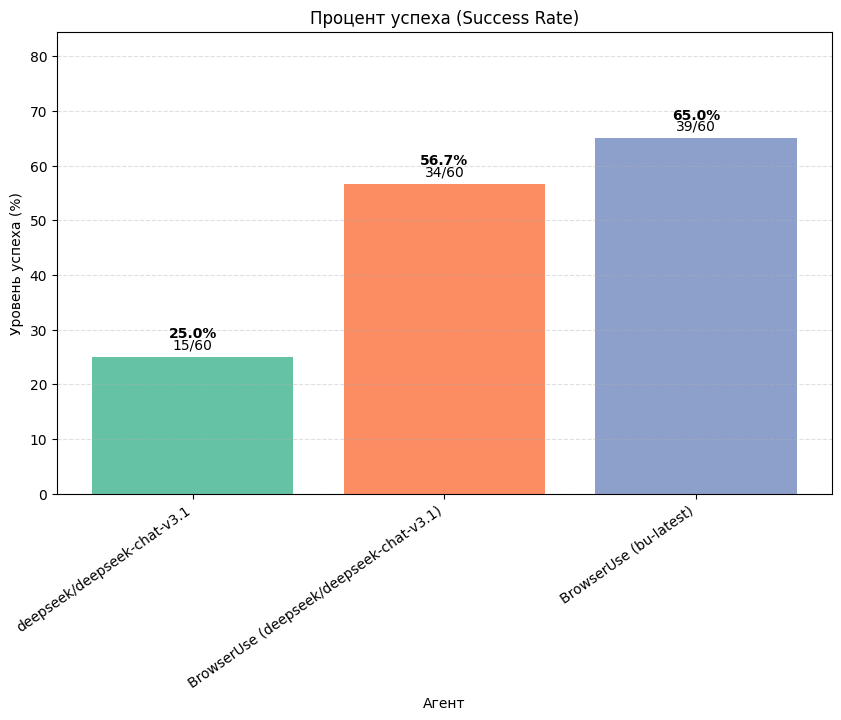

In [ ]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Set2(range(len(agents)))
bars = plt.bar(agents, analysis_df['Success Rate (%)'], color=colors)
for bar, label in zip(bars, analysis_df['Успех / всего']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, label, ha='center', va='bottom', fontsize=10)
    plt.text(bar.get_x() + bar.get_width() / 2, height + 3, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.ylim(0, max(analysis_df['Success Rate (%)']) * 1.3)
plt.xlabel('Агент')
plt.ylabel('Уровень успеха (%)')
plt.title('Процент успеха (Success Rate)')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

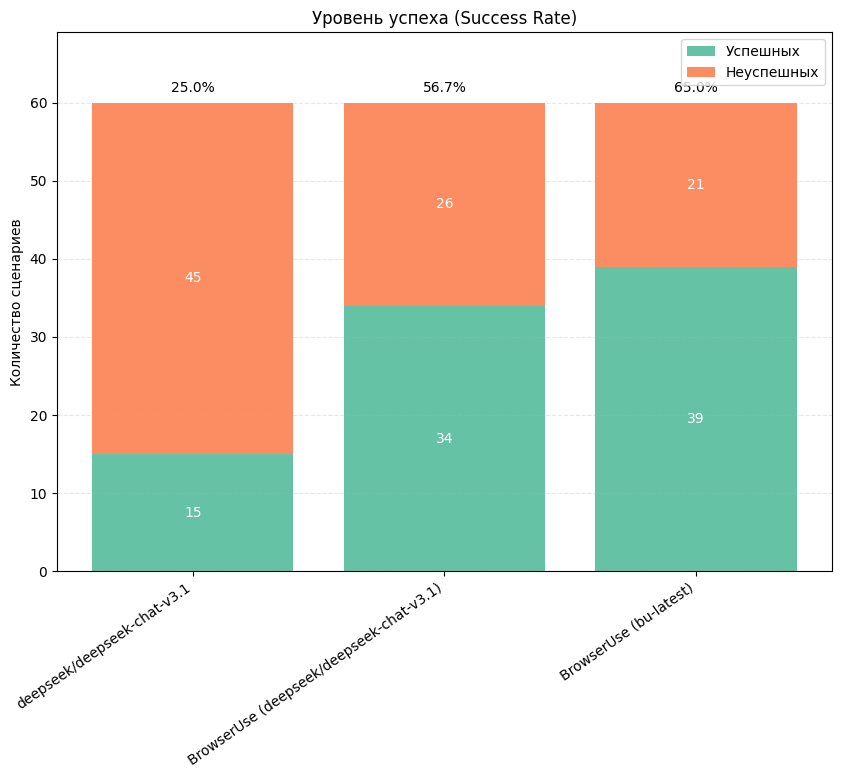

In [ ]:
plt.figure(figsize=(10, 7))
pos = range(len(agents))
colors = plt.cm.Set2(range(2))
plt.bar(pos, successful, label='Успешных', color=colors[0])
plt.bar(pos, failed, bottom=successful, label='Неуспешных', color=colors[1])
for i in pos:
    plt.text(i, successful[i] / 2, str(successful[i]), ha='center', va='center', color='white', fontsize=10)
    plt.text(i, successful[i] + failed[i] / 2, str(failed[i]), ha='center', va='center', color='white', fontsize=10)
    plt.text(i, successful[i] + failed[i] + 1, f'{success_rates[i]:.1f}%', ha='center', va='bottom', fontsize=10)
plt.xticks(pos, agents, rotation=35, ha='right')
plt.ylabel('Количество сценариев')
plt.title('Уровень успеха (Success Rate)')
plt.ylim(0, max([s + f for s, f in zip(successful, failed)]) * 1.15)
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

<Figure size 1200x600 with 0 Axes>

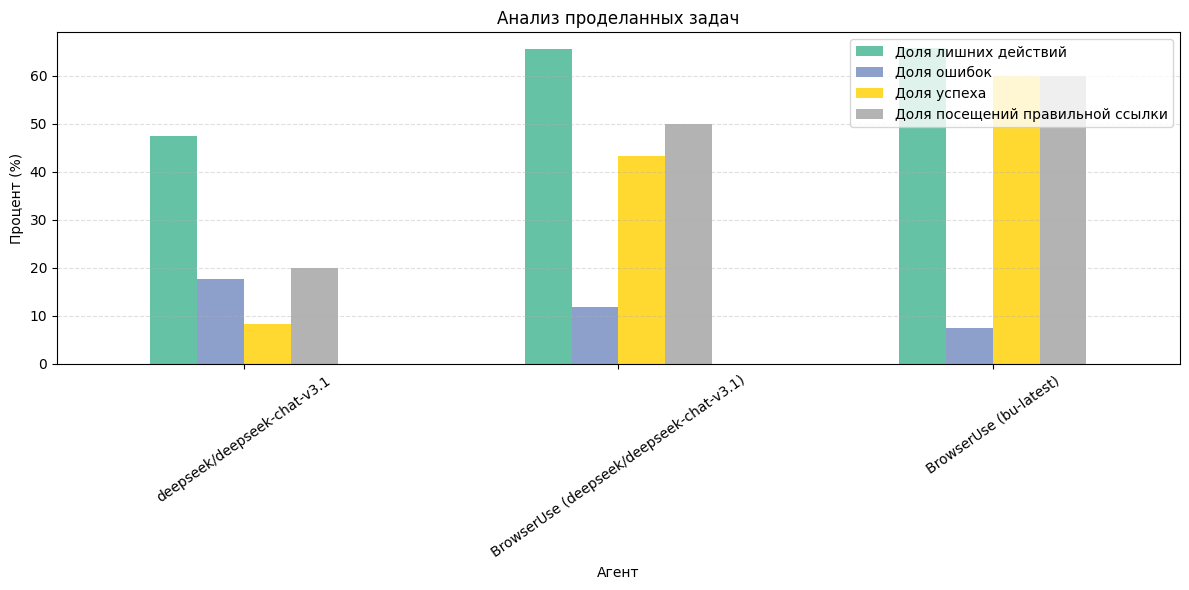

In [ ]:
plt.figure(figsize=(12, 6))
ratio_df = pd.DataFrame({
    'Агент': agents,
    'Доля лишних действий': useless_ratio,
    'Доля ошибок': error_ratio,
    'Доля успеха': stopped_rate,
    'Доля посещений правильной ссылки': visited_rate,
})
ratio_df_plot = ratio_df.set_index('Агент').copy()
ratio_df_plot['Доля лишних действий'] *= 100
ratio_df_plot['Доля ошибок'] *= 100
ratio_df_plot.plot(kind='bar', figsize=(12, 6), rot=35, colormap='Set2')
plt.ylabel('Процент (%)')
plt.title('Анализ проделанных задач')
plt.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

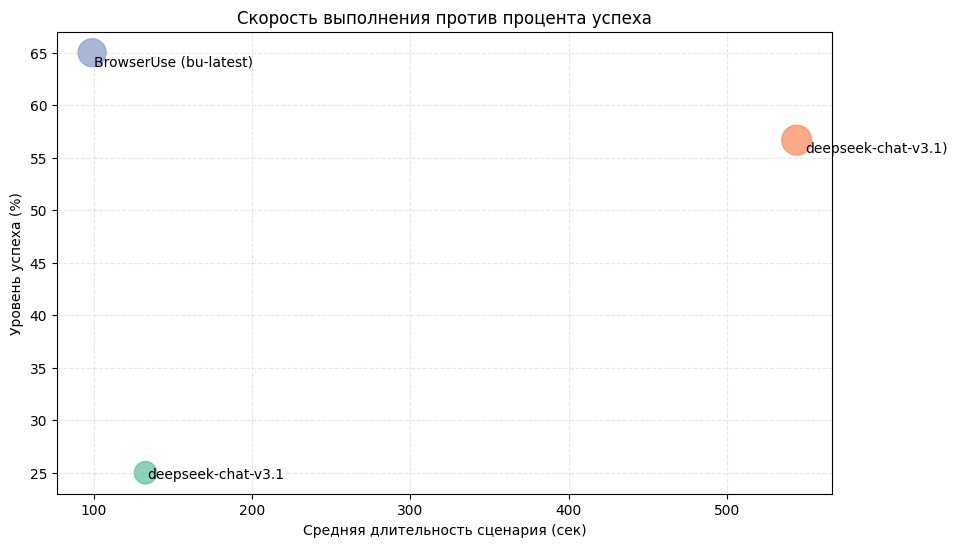

In [ ]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Set2(range(len(agents)))
plt.scatter(analysis_df['Avg Duration (sec)'], analysis_df['Success Rate (%)'],
            s=analysis_df['Avg Steps'] * 35, alpha=0.75, c=colors)
for i, agent in enumerate(agents):
    plt.text(analysis_df.loc[i, 'Avg Duration (sec)'] * 1.01,
             analysis_df.loc[i, 'Success Rate (%)'] * 0.98,
             agent.split('/')[-1], fontsize=10)
plt.xlabel('Средняя длительность сценария (сек)')
plt.ylabel('Уровень успеха (%)')
plt.title('Скорость выполнения против процента успеха')
plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.show()

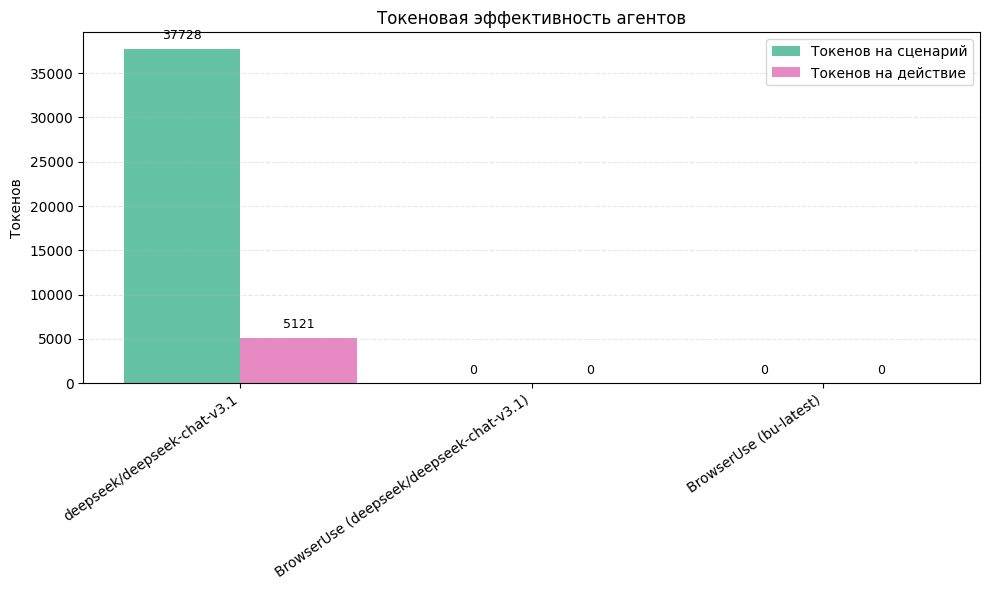

In [ ]:
plt.figure(figsize=(10, 6))
indices = range(len(agents))
colors = plt.cm.Set2(range(len(agents)))
colors2 = plt.cm.Set2(range(len(agents), 2*len(agents)))
bar1 = plt.bar(indices, analysis_df['Tokens / Scenario'], width=0.4, label='Токенов на сценарий', color=colors)
bar2 = plt.bar([i + 0.4 for i in indices], analysis_df['Tokens / Action'], width=0.4, label='Токенов на действие', color=colors2)
for bar in bar1 + bar2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + max(analysis_df['Tokens / Scenario']) * 0.02,
             f'{height:.0f}', ha='center', va='bottom', fontsize=9)
plt.xticks([i + 0.2 for i in indices], agents, rotation=35, ha='right')
plt.ylabel('Токенов')
plt.title('Токеновая эффективность агентов')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Сравнение средних шагов: общие vs успешные

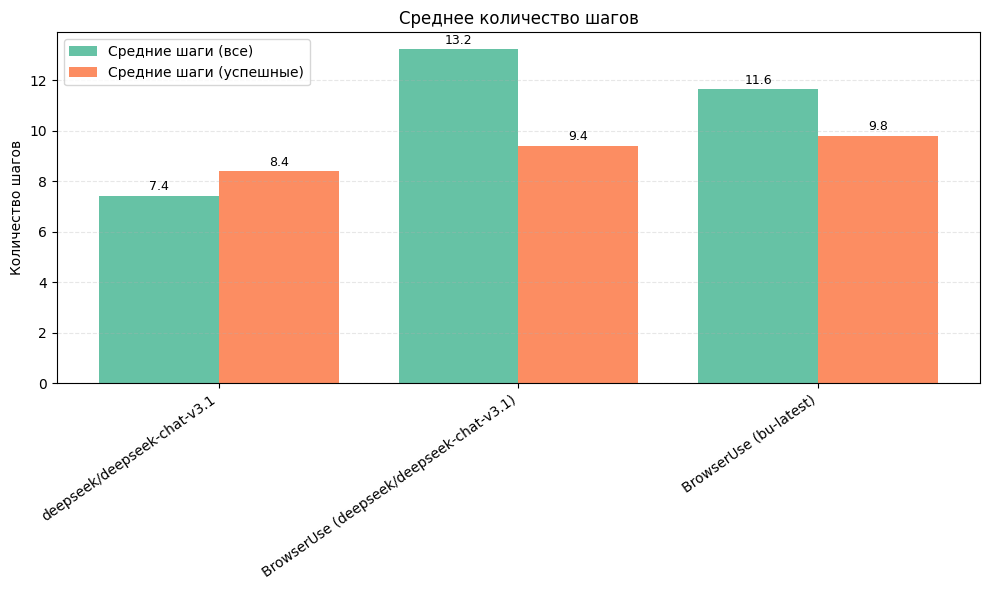

In [ ]:
plt.figure(figsize=(10, 6))
indices = range(len(agents))
colors = plt.cm.Set2(range(2))
bar1 = plt.bar(indices, analysis_df['Avg Steps'], width=0.4, label='Средние шаги (все)', color=colors[0])
bar2 = plt.bar([i + 0.4 for i in indices], analysis_df['Avg Steps Success'], width=0.4, label='Средние шаги (успешные)', color=colors[1])
for bar in bar1 + bar2:
    height = bar.get_height()
    if not pd.isna(height):
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.1f}', ha='center', va='bottom', fontsize=9)
plt.xticks([i + 0.2 for i in indices], agents, rotation=35, ha='right')
plt.ylabel('Количество шагов')
plt.title('Среднее количество шагов')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Доля ошибок (Error Ratio)

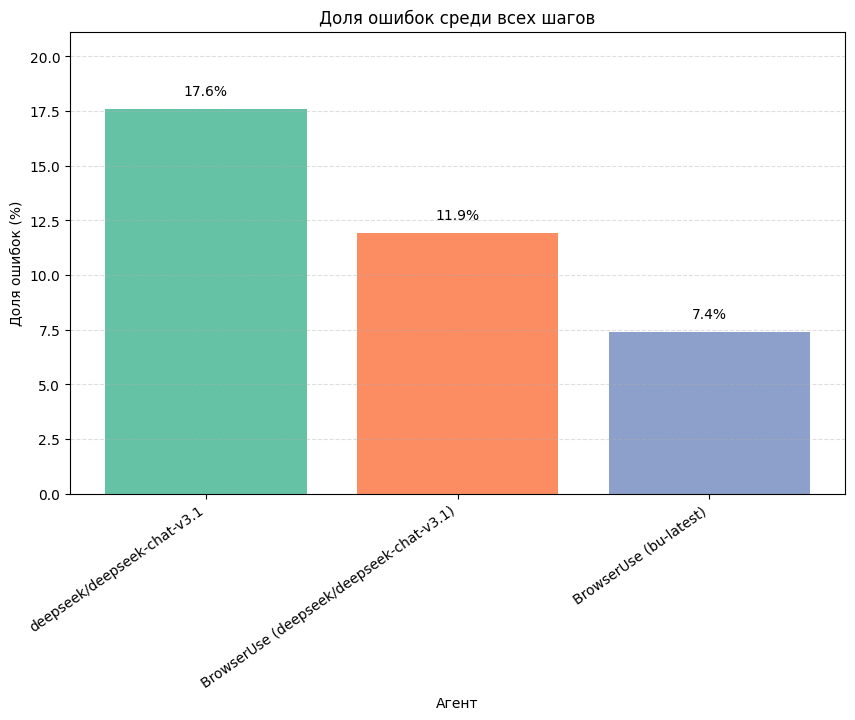

In [ ]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Set2(range(len(agents)))
bars = plt.bar(agents, [r * 100 for r in error_ratio], color=colors)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
plt.ylim(0, max([r * 100 for r in error_ratio]) * 1.2)
plt.xlabel('Агент')
plt.ylabel('Доля ошибок (%)')
plt.title('Доля ошибок среди всех шагов')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# Метрики пути

In [ ]:
with open('benchmark/benchmarks.json', 'r', encoding='utf-8') as f:
    benchmarks = json.load(f)

benchmarks_dict = {b['id']: b for b in benchmarks}

# Вычисление метрик пути
path_metrics = {}
for item in data:
    agent_name = item['agent_name']
    path_metrics[agent_name] = {'step_success_rates': [], 'matching_rates': [], 'efficiencies': []}
    for result in item['results']:
        scenario_id = result['scenario_id']
        if scenario_id not in benchmarks_dict:
            continue
        trace = benchmarks_dict[scenario_id]['trace']
        trajectory = result['trajectory']

        # Step Success Rate
        k = 0
        for i in range(min(len(trace), len(trajectory))):
            trace_xpath = trace[i]['x_path']
            if 'raw_action' not in trajectory[i] or not trajectory[i]['raw_action'] or 'interacted_element' not in trajectory[i]['raw_action'] or not trajectory[i]['raw_action']['interacted_element'] or 'x_path' not in trajectory[i]['raw_action']['interacted_element']:
                break
            agent_xpath = trajectory[i]['raw_action']['interacted_element']['x_path']
            if trace_xpath in agent_xpath and trace[i]['action'] == trajectory[i]['action']:
                k += 1
            else:
                break
        step_success_rate = k / len(trace) * 100 if trace else 0

        # Matching Rate
        matches = 0
        for t_step in trace:
            for a_step in trajectory:
                if 'raw_action' in a_step and a_step['raw_action'] and 'interacted_element' in a_step['raw_action'] and a_step['raw_action']['interacted_element'] and 'x_path' in a_step['raw_action']['interacted_element']:
                    agent_xpath = a_step['raw_action']['interacted_element']['x_path']
                    if t_step['x_path'] in agent_xpath and t_step['action'] == a_step['action']:
                        matches += 1
                        break
        matching_rate = matches / len(trace) * 100 if trace else 0

        # Эффективность
        efficiency = len(trace) / len(trajectory) if trajectory else 0

        path_metrics[agent_name]['step_success_rates'].append(step_success_rate)
        path_metrics[agent_name]['matching_rates'].append(matching_rate)
        path_metrics[agent_name]['efficiencies'].append(efficiency)

# Усреднение по сценариям
for agent in path_metrics:
    path_metrics[agent]['avg_step_success_rate'] = sum(path_metrics[agent]['step_success_rates']) / len(path_metrics[agent]['step_success_rates']) if path_metrics[agent]['step_success_rates'] else 0
    path_metrics[agent]['avg_matching_rate'] = sum(path_metrics[agent]['matching_rates']) / len(path_metrics[agent]['matching_rates']) if path_metrics[agent]['matching_rates'] else 0
    path_metrics[agent]['avg_efficiency'] = sum(path_metrics[agent]['efficiencies']) / len(path_metrics[agent]['efficiencies']) if path_metrics[agent]['efficiencies'] else 0


analysis_df['Step Success Rate (%)'] = [path_metrics.get(agent, {}).get('avg_step_success_rate', 0) for agent in agents]
analysis_df['Matching Rate (%)'] = [path_metrics.get(agent, {}).get('avg_matching_rate', 0) for agent in agents]
analysis_df['Эффективность'] = [path_metrics.get(agent, {}).get('avg_efficiency', 0) for agent in agents]

analysis_df

,Agent,Всего сценариев,Успешных,Неуспешных,Success Rate (%),Avg Duration (sec),Avg Steps,Avg Steps Success,Total Actions,Useless Actions Ratio,Error Ratio,Stopped Correctly Rate,Visited Eval URL Rate,Tokens / Scenario,Tokens / Action,Успех / всего,Step Success Rate (%),Matching Rate (%),Эффективность
0,deepseek/deepseek-chat-v3.1,60,15,45,25.00,132.49,7.42,8.40,442,0.475,0.176,8.33,20.0,37727.583333,5121.391403,15/60,0.000000,0.000000,1.087081
1,BrowserUse (deepseek/deepseek-chat-v3.1),60,34,26,56.67,544.16,13.23,9.41,996,0.656,0.119,43.33,50.0,0.000000,0.000000,34/60,19.550223,44.944269,0.371078
2,BrowserUse (bu-latest),60,39,21,65.00,98.78,11.63,9.79,1131,0.658,0.074,60.00,60.0,0.000000,0.000000,39/60,14.880189,36.726523,0.364223


## Step Success Rate
Насколько далеко агент смог пройти по «идеальному пути» без единой ошибки. Это метрика целостности пути. Если агент на втором шаге из десяти нажал не туда, SSR будет всего 10%, даже если потом он вернулся на верный путь.

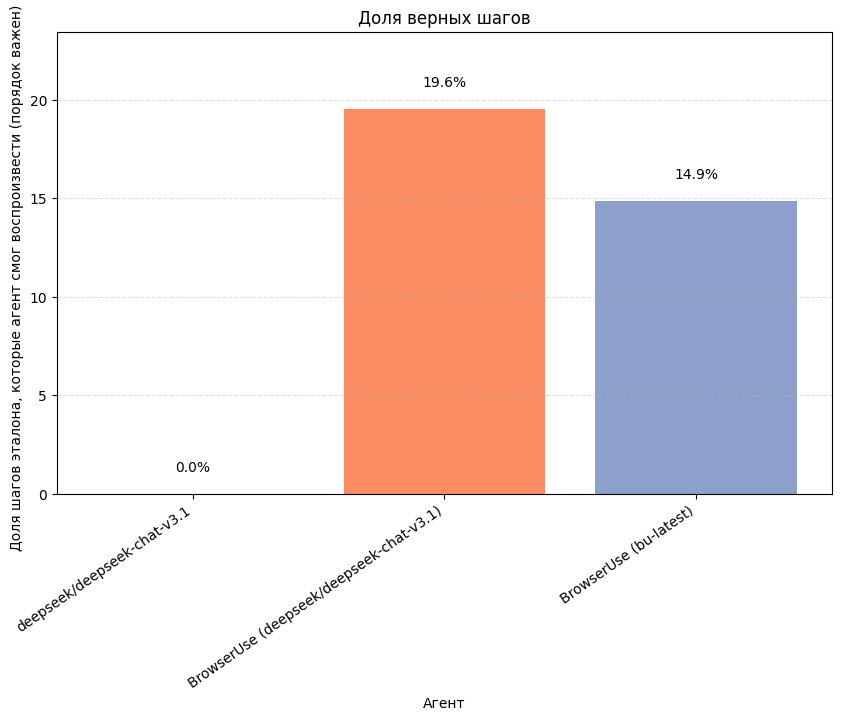

In [ ]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Set2(range(len(agents)))
bars = plt.bar(agents, analysis_df['Step Success Rate (%)'], color=colors)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
plt.ylim(0, max(analysis_df['Step Success Rate (%)']) * 1.2)
plt.xlabel('Агент')
plt.ylabel('Доля шагов эталона, которые агент смог воспроизвести (порядок важен) (%)')
plt.title('Доля верных шагов')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

## Matching Rate
Какую часть необходимых действий агент совершил в принципе, неважно в каком порядке и сколько лишнего он сделал между ними.

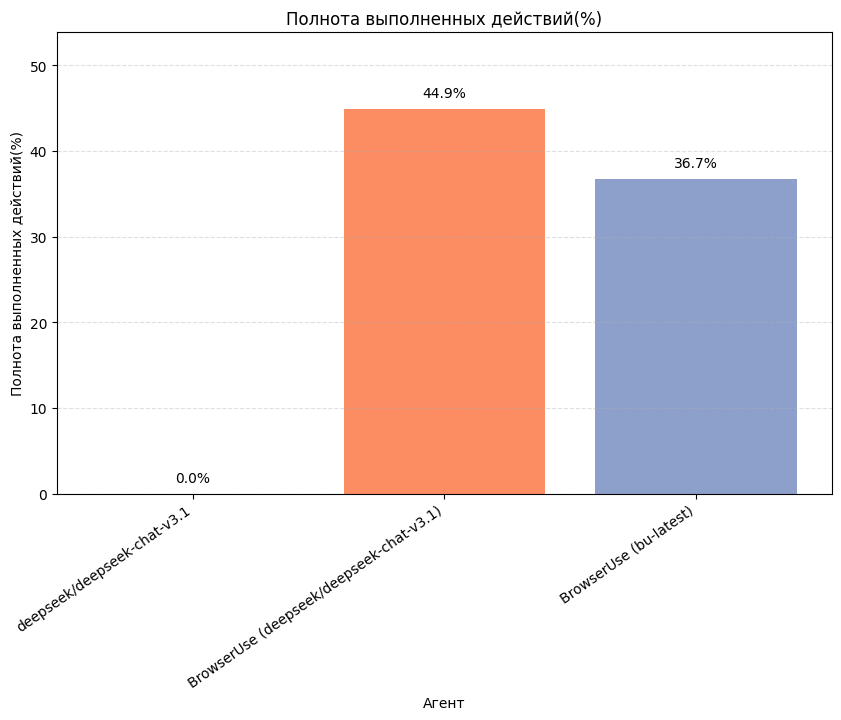

In [ ]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Set2(range(len(agents)))
bars = plt.bar(agents, analysis_df['Matching Rate (%)'], color=colors)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
plt.ylim(0, max(analysis_df['Matching Rate (%)']) * 1.2)
plt.xlabel('Агент')
plt.ylabel('Полнота выполненных действий(%)')
plt.title('Полнота выполненных действий(%)')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

## Эффективность

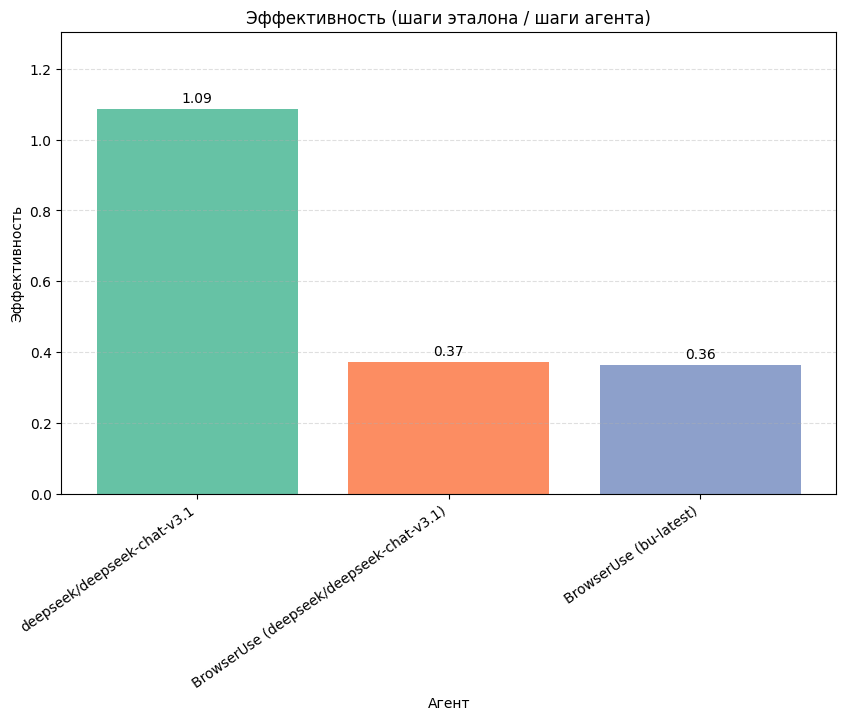

In [ ]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Set2(range(len(agents)))
bars = plt.bar(agents, analysis_df['Эффективность'], color=colors)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=10)
plt.ylim(0, max(analysis_df['Эффективность']) * 1.2)
plt.xlabel('Агент')
plt.ylabel('Эффективность')
plt.title('Эффективность (шаги эталона / шаги агента)')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# Анализ сценариев

In [ ]:
with open('benchmark/benchmarks.json', 'r', encoding='utf-8') as f:
    benchmarks = json.load(f)

types_count = {}
difficulties_count = {}
steps_list = []
for b in benchmarks:
    t = b['type']
    types_count[t] = types_count.get(t, 0) + 1
    d = b['difficulty']
    difficulties_count[d] = difficulties_count.get(d, 0) + 1
    steps_list.append(len(b['trace']))

difficulty_order = ['easy', 'medium', 'hard']
difficulties_count = {key: difficulties_count[key] for key in difficulty_order if key in difficulties_count}

type_translation = {
    'travel': 'Путешествия',
    'info': 'Информация',
    'entertainment': 'Развлечения',
    'shopping': 'Покупки'
}
types_count = {type_translation.get(key, key): value for key, value in types_count.items()}

difficulty_translation = {
    'easy': 'Легкий (1-5 шагов)',
    'medium': 'Средний (6-9 шагов)',
    'hard': 'Сложный (10+ шагов)'
}
difficulties_count = {difficulty_translation.get(key, key): value for key, value in difficulties_count.items()}

print("Types:", types_count)
print("Difficulties:", difficulties_count)

Types: {'Путешествия': 21, 'Информация': 15, 'Развлечения': 12, 'Покупки': 12}
Difficulties: {'Легкий (1-5 шагов)': 28, 'Средний (6-9 шагов)': 17, 'Сложный (10+ шагов)': 15}


## Распределение по типам сценариев

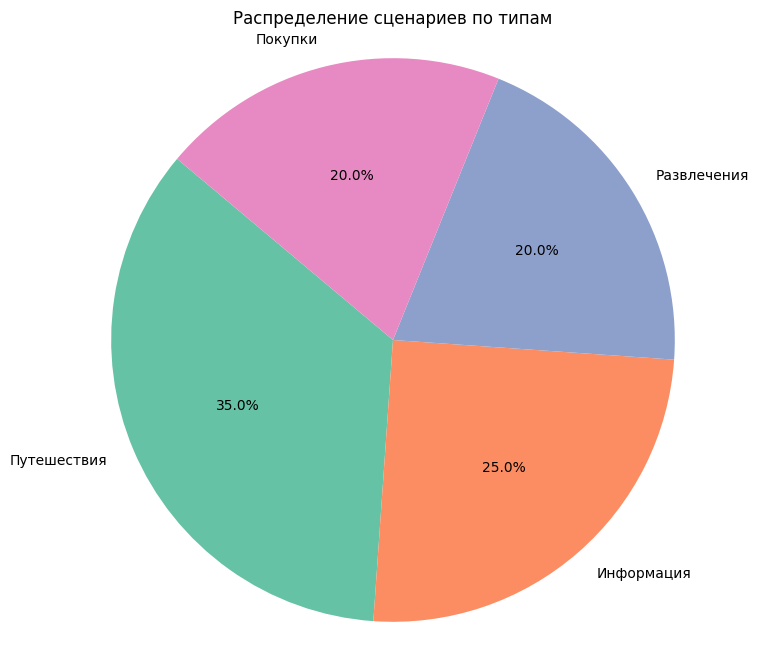

In [ ]:
plt.figure(figsize=(8, 8))
labels = list(types_count.keys())
sizes = list(types_count.values())
colors = plt.cm.Set2(range(len(labels)))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Распределение сценариев по типам')
plt.axis('equal')
plt.show()

# Распределение по сложности сценариев

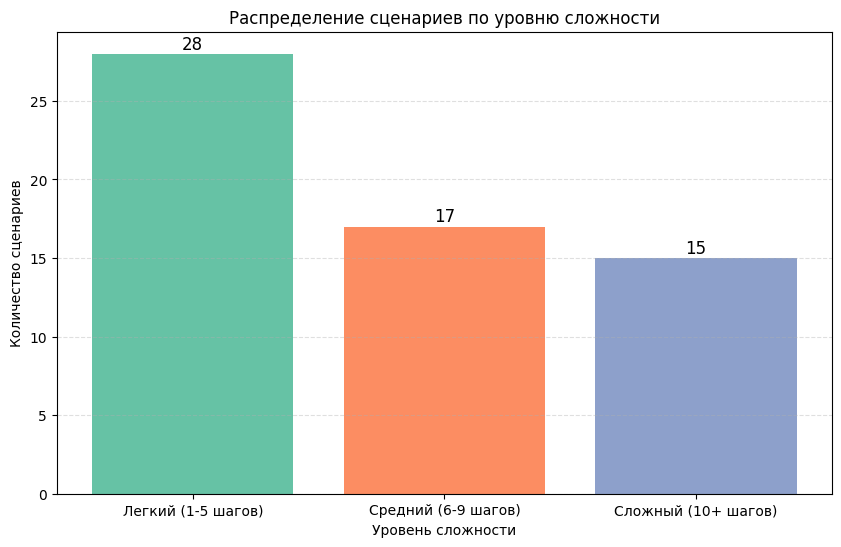

In [ ]:
plt.figure(figsize=(10, 6))
difficulties = list(difficulties_count.keys())
counts = list(difficulties_count.values())
colors = plt.cm.Set2(range(len(difficulties)))
bars = plt.bar(difficulties, counts, color=colors)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05, str(count), ha='center', va='bottom', fontsize=12)
plt.xlabel('Уровень сложности')
plt.ylabel('Количество сценариев')
plt.title('Распределение сценариев по уровню сложности')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# Распределение по числу шагов

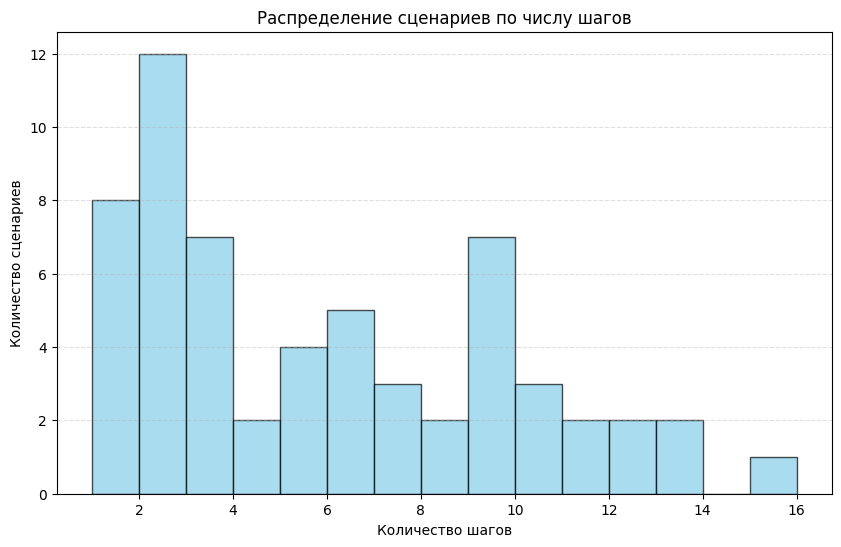

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(steps_list, bins=range(min(steps_list), max(steps_list) + 2), edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Количество шагов')
plt.ylabel('Количество сценариев')
plt.title('Распределение сценариев по числу шагов')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# Среднее количество шагов по типам сценариев

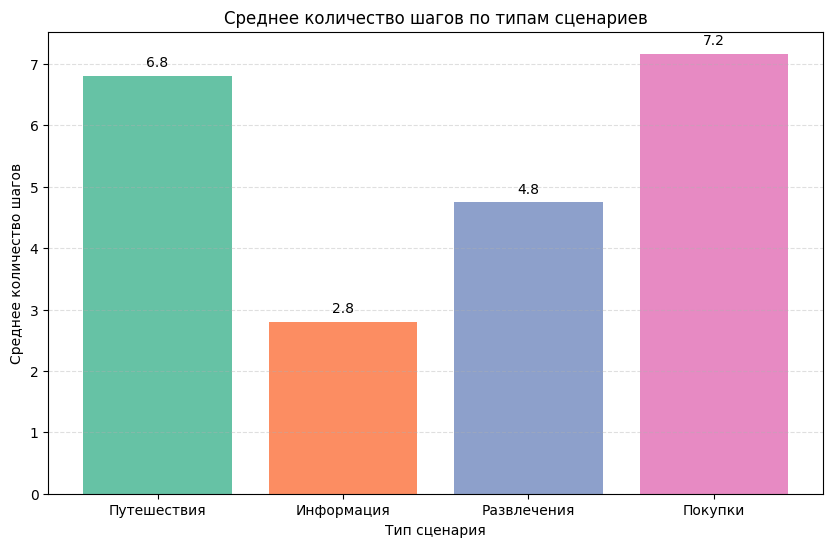

In [ ]:
from collections import defaultdict

steps_by_type = defaultdict(list)
for b in benchmarks:
    steps_by_type[b['type']].append(len(b['trace']))

avg_steps_by_type = {}
for t, steps in steps_by_type.items():
    russian_t = type_translation.get(t, t)
    avg_steps_by_type[russian_t] = sum(steps) / len(steps)

plt.figure(figsize=(10, 6))
types = list(avg_steps_by_type.keys())
avgs = list(avg_steps_by_type.values())
colors = plt.cm.Set2(range(len(types)))
bars = plt.bar(types, avgs, color=colors)
for bar, avg in zip(bars, avgs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1, f'{avg:.1f}',
             ha='center', va='bottom', fontsize=10)
plt.xlabel('Тип сценария')
plt.ylabel('Среднее количество шагов')
plt.title('Среднее количество шагов по типам сценариев')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# Среднее количество шагов по сложности

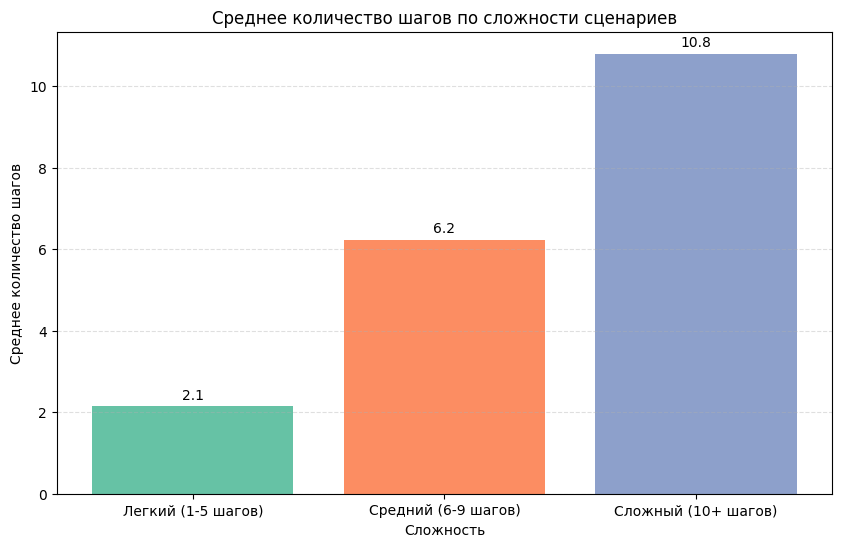

In [ ]:
from collections import defaultdict

steps_by_difficulty = defaultdict(list)
for b in benchmarks:
    steps_by_difficulty[b['difficulty']].append(len(b['trace']))

avg_steps_by_difficulty = {}
for d in difficulty_order:
    if d in steps_by_difficulty:
        steps = steps_by_difficulty[d]
        russian_d = difficulty_translation.get(d, d)
        avg_steps_by_difficulty[russian_d] = sum(steps) / len(steps)

plt.figure(figsize=(10, 6))
difficulties = list(avg_steps_by_difficulty.keys())
avgs = list(avg_steps_by_difficulty.values())
colors = plt.cm.Set2(range(len(difficulties)))
bars = plt.bar(difficulties, avgs, color=colors)
for bar, avg in zip(bars, avgs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1, f'{avg:.1f}',
             ha='center', va='bottom', fontsize=10)
plt.xlabel('Сложность')
plt.ylabel('Среднее количество шагов')
plt.title('Среднее количество шагов по сложности сценариев')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()